In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from functools import reduce

import gc
import itertools
import glob
import os

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484


In [2]:
# directory where the files are stored
folder = "/home/pira/Documenti/PoD/LCP/LCP_B/ALICE/CombDataMC"
all_files = glob.glob(os.path.join(folder, "*.pkl"))
# choose eventually which columns to exclude:
useless_cols = ["neg_pt", "pos_pt"]

# choose how many files to load
x = 60                              # change this to the number of files you want (or your RAM can afford..)
files_to_load = all_files[:x]

print(f"Found {len(all_files)} files. Loading up to {len(files_to_load)} files")


Found 60 files. Loading up to 60 files


In [3]:
# initialization
final_results = pd.DataFrame()

# UPLOAD ---------------------------------------------------------------------
for i, f in enumerate(files_to_load, start=1):
    
    # UPLOAD DATA excluding useless columns:
    df = pd.read_pickle(f)
    df = df.drop(columns=useless_cols)

    # DEFINING MASKS to decrease the number of columns by summarizing them:
    mask_true_d0 = (
        (df["track_pdg_pos"] == 211 ) &
        (df["track_pdg_neg"] == -321 ) &
        (df["mother_pdg_pos"] == 421) &
        (df["mother_pdg_neg"] == 421) &
        (df["beauty_pdg_pos"] == 0) &
        (df["beauty_pdg_neg"] == 0) &
        (df["mother_N_final_state_pos"] == 2) &
        (df["mother_N_final_state_neg"] == 2) &
        (df['mother_orig_ind_pos'] == df['mother_orig_ind_neg'] )
    )
    mask_true_anti_d0 = (
        (df["track_pdg_pos"] == 321) &
        (df["track_pdg_neg"] == -211) &
        (df["mother_pdg_pos"] == -421) &
        (df["mother_pdg_neg"] == -421) &
        (df["beauty_pdg_pos"] == 0) &
        (df["beauty_pdg_neg"] == 0) &
        (df["mother_N_final_state_pos"] == 2) &
        (df["mother_N_final_state_neg"] == 2) &
        (df['mother_orig_ind_pos'] == df['mother_orig_ind_neg'] )
    )
    mask_background = ( (~mask_true_d0) & (~mask_true_anti_d0) )

    # SUMMARIZE some columns:
    df["truth"] = np.select( [mask_true_d0, mask_true_anti_d0] , [1, -1], default=0)
    summarized_cols = ["track_pdg_pos", "track_pdg_neg", "mother_pdg_pos", "mother_pdg_neg", "beauty_pdg_pos", "beauty_pdg_neg",
                     "mother_N_final_state_pos", "mother_N_final_state_neg", "mother_orig_ind_pos", "mother_orig_ind_neg"]
    df = df.drop(columns=summarized_cols)

    # FINAL single file uploaded:
    final_results = pd.concat([final_results, df], ignore_index=True)
    
    # free memory
    del df
    gc.collect()
    
    # debug
    print(f"{i}", end=' ')

print(f"\nFinished: loaded {i} files out of {len(all_files)} available.")

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 
Finished: loaded 60 files out of 60 available.


In [4]:
print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 53_987_942 rows and 17 columns.
It occupies 7_002.22 MB in RAM memory


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,neg_TPCka,neg_TOFka,neg_fDcaXY,pos_TPCpi,pos_TOFpi,pos_fDcaXY,neg_TPCpi,neg_TOFpi,pos_TPCka,pos_TOFka,truth
0,1.296588e-05,1.322113,1.348056,0.756649,0.006524,0.013159,-1.974950,-22.784950,0.004469,0.979456,-999.000000,0.002902,1.022238,4.726245,-3.853288,-999.000000,0
1,1.270784e-02,1.954415,1.958980,0.200775,8.582311,-0.965375,-0.328094,-21.626837,-0.033259,0.518377,3336.820312,-0.382089,-0.413220,-7.997087,0.168876,311.423248,0
2,-7.606078e-04,3.261606,3.139954,4.169398,0.047901,0.954646,-0.328094,-21.626837,-0.033259,3.921944,-8.304654,0.022869,-0.413220,-7.997087,7.316254,-9.366850,0
3,-3.118734e-05,1.253627,1.303864,1.506492,0.046503,0.727795,-0.328094,-21.626837,-0.033259,1.456452,-7.703940,0.000938,-0.413220,-7.997087,-0.946266,-27.590778,0
4,3.289507e-03,3.183207,3.114732,2.083273,0.213750,-0.376830,-0.328094,-21.626837,-0.033259,-1.726586,-999.000000,-0.098906,-0.413220,-7.997087,-0.618109,-999.000000,0
53987937,4.637617e-07,1.354230,1.564787,2.709808,0.001318,-0.329405,1.811227,-999.000000,-0.000479,0.221203,-999.000000,-0.000967,-0.347903,-999.000000,-2.930717,-999.000000,0
53987938,-3.434773e-07,1.633574,1.934335,2.193558,0.002648,0.471612,1.811227,-999.000000,-0.000479,0.707322,-999.000000,0.000716,-0.347903,-999.000000,-10.810585,-999.000000,0
53987939,2.069125e-07,1.667647,1.722397,3.629359,0.000836,0.245840,1.811227,-999.000000,-0.000479,-1.561130,-999.000000,-0.000432,-0.347903,-999.000000,-0.393278,-999.000000,0
53987940,1.627491e-06,1.390597,1.546009,2.804238,0.006702,0.205711,1.811227,-999.000000,-0.000479,8.473253,-999.000000,-0.003394,-0.347903,-999.000000,6.439966,-999.000000,0
53987941,6.694435e-07,3.687731,3.714901,1.364379,0.006705,-0.311955,1.811227,-999.000000,-0.000479,-1.339525,-999.000000,-0.001396,-0.347903,-999.000000,0.089856,-999.000000,0


In [5]:
#Look at the list of variables in the dataframe
final_results.columns

Index(['dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'decay_length',
       'cos_pointing', 'neg_TPCka', 'neg_TOFka', 'neg_fDcaXY', 'pos_TPCpi',
       'pos_TOFpi', 'pos_fDcaXY', 'neg_TPCpi', 'neg_TOFpi', 'pos_TPCka',
       'pos_TOFka', 'truth'],
      dtype='object')

In [6]:
# let's define the masks for the MC info on TRUE D0 and anti-D0:
mask_true_d0 = ( final_results["truth"] == 1 )
mask_true_anti_d0 = ( final_results["truth"] == -1 )
mask_signal = ( (mask_true_d0) | (mask_true_anti_d0) )
mask_background = ( final_results["truth"] == 0 )

In [7]:
d0_tot = np.sum( mask_true_d0 )
anti_d0_tot = np.sum( mask_true_anti_d0 )
signal_tot = d0_tot + anti_d0_tot
num_bg_pairs = np.sum( mask_background )
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print(f"Number of background pairs: {num_bg_pairs:_}")
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

Number of D0:       10122
Number of anti-D0:  10650
Number of background pairs: 53_967_170
Fraction of D0 and anti-D0 over total: 0.0385%


In [8]:
# cut sul coseno di pointing
final_results = final_results[final_results['cos_pointing']>0.9]

In [9]:
# single cuts:
cut_neg_TOFka = 7.3
cut_neg_TPCka = 2
cut_pos_TOFka = 7.8
cut_pos_TPCka = 1.8
cut_cos_pointing = 0.96


# we create the cuts as a mask:
cuts = (
    (
        ( (final_results['neg_TOFka'] > -cut_neg_TOFka) & (final_results['neg_TOFka'] < cut_neg_TOFka) &
          (final_results['neg_TPCka'] > -cut_pos_TOFka) & (final_results['neg_TPCka'] < cut_pos_TOFka) )
        |
        ( (final_results['pos_TOFka'] > -cut_pos_TOFka) & (final_results['pos_TOFka'] < cut_pos_TOFka) &
          (final_results['pos_TPCka'] > -cut_pos_TPCka) & (final_results['pos_TPCka'] < cut_pos_TPCka) )
    )
    &
    (final_results['cos_pointing'] > cut_cos_pointing) #&
    # p_t window:
    #(final_results['pt'] > 2) & (final_results['pt'] < 8)
)


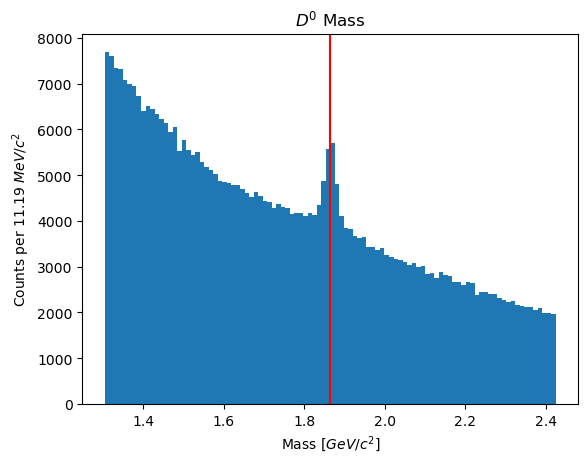

In [10]:
MIN_MASS, MAX_MASS = 0.7*m_d0, 1.3*m_d0
N_BINS = 100

# prepare the invariant mass data
data_inv_mass  = final_results.loc[cuts, ['inv_mass','pt']].values
data_anti_mass  = final_results.loc[cuts, ['anti_mass','pt']].values
data = pd.DataFrame(np.concatenate([data_inv_mass, data_anti_mass]), columns=['mass', 'pt'])

# plot the data
plt.hist(data['mass'], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass")
#plt.savefig("D0_Mass_MC.png")
plt.show()

In [11]:
# let's define the masks for the MC info on TRUE D0 and anti-D0:
mask_true_d0 = ( final_results["truth"] == 1 )
mask_true_anti_d0 = ( final_results["truth"] == -1 )
mask_signal = ( (mask_true_d0) | (mask_true_anti_d0) )
mask_background = ( final_results["truth"] == 0 )

In [12]:
d0_tot = np.sum( mask_true_d0 )
anti_d0_tot = np.sum( mask_true_anti_d0 )
signal_tot = d0_tot + anti_d0_tot
num_bg_pairs = np.sum( mask_background )
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print(f"Number of background pairs: {num_bg_pairs:_}")
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

Number of D0:       5230
Number of anti-D0:  5561
Number of background pairs: 6_518_987
Fraction of D0 and anti-D0 over total: 0.1653%


Ratio (reflex/sign): 0.7561978846663535
Ratio (reflex/sign): 0.9165099166710388
Ratio (reflex/sign): 0.7870622932937898
Ratio (reflex/sign): 0.7827976934624787
Ratio (reflex/sign): 0.6055843333820375
Ratio (reflex/sign): 0.5491299749040341


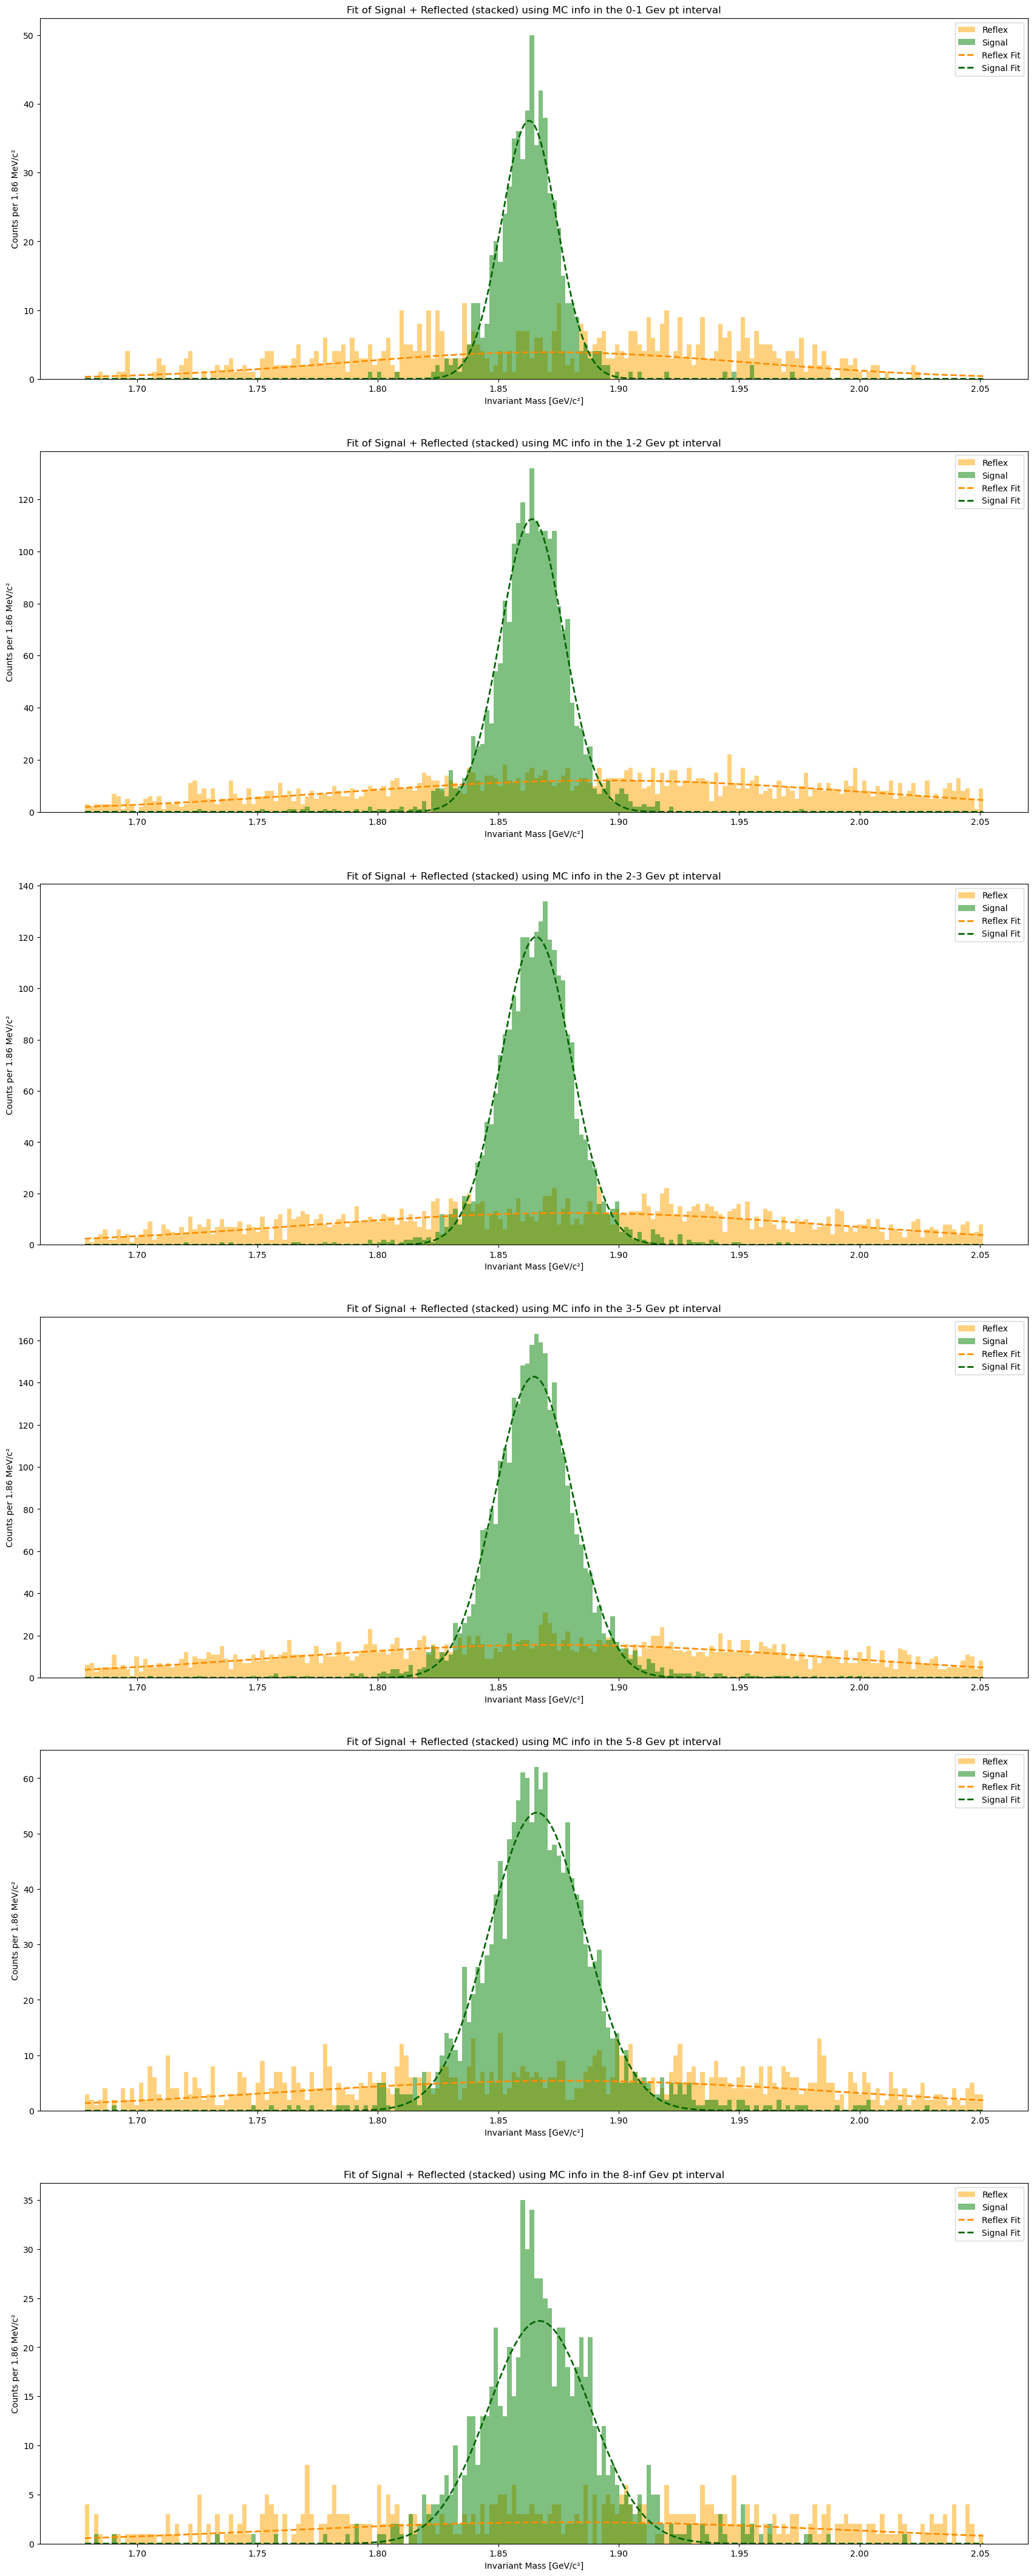

In [13]:
# --- Fit function: double Gaussian---
def fit_gauss_mc(x, k, mu1, sigma1):
    return k * norm.pdf(x, loc=mu1, scale=sigma1) 

# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 200
binsize = (MAX_MASS - MIN_MASS)/N_BINS
# --- Initial parameter guesses ---
k_param = 100
gauss_params = [m_d0, 0.05]

# define pt intervals
pt_extremes = [[0, 1] , [1,2] , [2,3] , [3,5] , [5,8] , [8, np.inf]]
times = len(pt_extremes)

# define the figures
fig, axs = plt.subplots( nrows = times, ncols = 1, figsize = ( 21, 9 * times ) )

# list to store the values of k_ref/k_sig
k_ref_sig_pt = []

# perform the fit
for i in range( times ) :
    pt_lim = pt_extremes[ i ]
    ax = axs[ i ]

    # pt mask
    mask_pt_range = (final_results['pt'] >= pt_lim[0]) & (final_results['pt'] < pt_lim[1])

    # Histogram of signal and rflected part data only without cuts
    # reflected part:
    data_inv_mass_true_ref   = final_results.loc[ mask_true_d0 & mask_pt_range, 'anti_mass'].values
    data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0 & mask_pt_range, 'inv_mass'].values
    reflex_data = np.concatenate( [ data_inv_mass_true_ref, data_anti_mass_true_ref] )
    # signal:
    data_inv_mass_true   = final_results.loc[ mask_true_d0 & mask_pt_range, 'inv_mass'].values
    data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & mask_pt_range, 'anti_mass'].values
    signal_data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
    
    # HISTOGRAM:
    # ------- reflex component:
    reflex_counts, reflex_edges, _ = ax.hist(reflex_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Reflex', color='orange')
    reflex_centers = (reflex_edges[:-1] + reflex_edges[1:]) / 2.0
    # poisson errors:
    sigma_reflex_hist = np.sqrt(reflex_counts)
    sigma_reflex_hist = np.clip(sigma_reflex_hist, 1, None)  # avoid zeros
    # ------- signal:
    sign_counts, sign_edges, _ = ax.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
    sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
    # poisson errors:
    sigma_sign_hist = np.sqrt(sign_counts)
    sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros
    
    # FIT:
    sign_fit_res = curve_fit( fit_gauss_mc, xdata = sign_centers, ydata = sign_counts, sigma = sigma_sign_hist,
                                p0 = [k_param, 
                                      gauss_params[0], gauss_params[1]
                                     ]
                            )
    sign_params = sign_fit_res[0]
    mu_sign, sigma_sign = sign_params[1], sign_params[2]
    k_sign = sign_params[0]
    # ----
    reflex_fit_res = curve_fit( fit_gauss_mc, xdata = reflex_centers, ydata = reflex_counts, sigma = sigma_reflex_hist,
                                p0 = [k_param, 
                                      gauss_params[0], gauss_params[1]
                                     ]
                            )
    reflex_params = reflex_fit_res[0]
    mu_reflex, sigma_reflex = reflex_params[1], reflex_params[2]
    k_reflex = reflex_params[0]
    
    # PRINT:
    ratio_from_fit = k_reflex/k_sign
    k_ref_sig_pt.append(ratio_from_fit)
    print(f"Ratio (reflex/sign): {ratio_from_fit}")
    
    # PLOT of fitted curves:
    x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
    ax.plot(x_fit, fit_gauss_mc(x_fit, k_reflex, mu_reflex, sigma_reflex), '--', color='darkorange', linewidth=2, label='Reflex Fit')
    ax.plot(x_fit, fit_gauss_mc(x_fit, k_sign, mu_sign, sigma_sign), '--', color='darkgreen', linewidth=2, label='Signal Fit')
    
    
    ax.set_xlabel("Invariant Mass [GeV/c²]")
    ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
    ax.set_title(f"Fit of Signal + Reflected (stacked) using MC info in the {pt_lim[0]}-{pt_lim[1]} Gev pt interval")
    ax.legend()

plt.show()


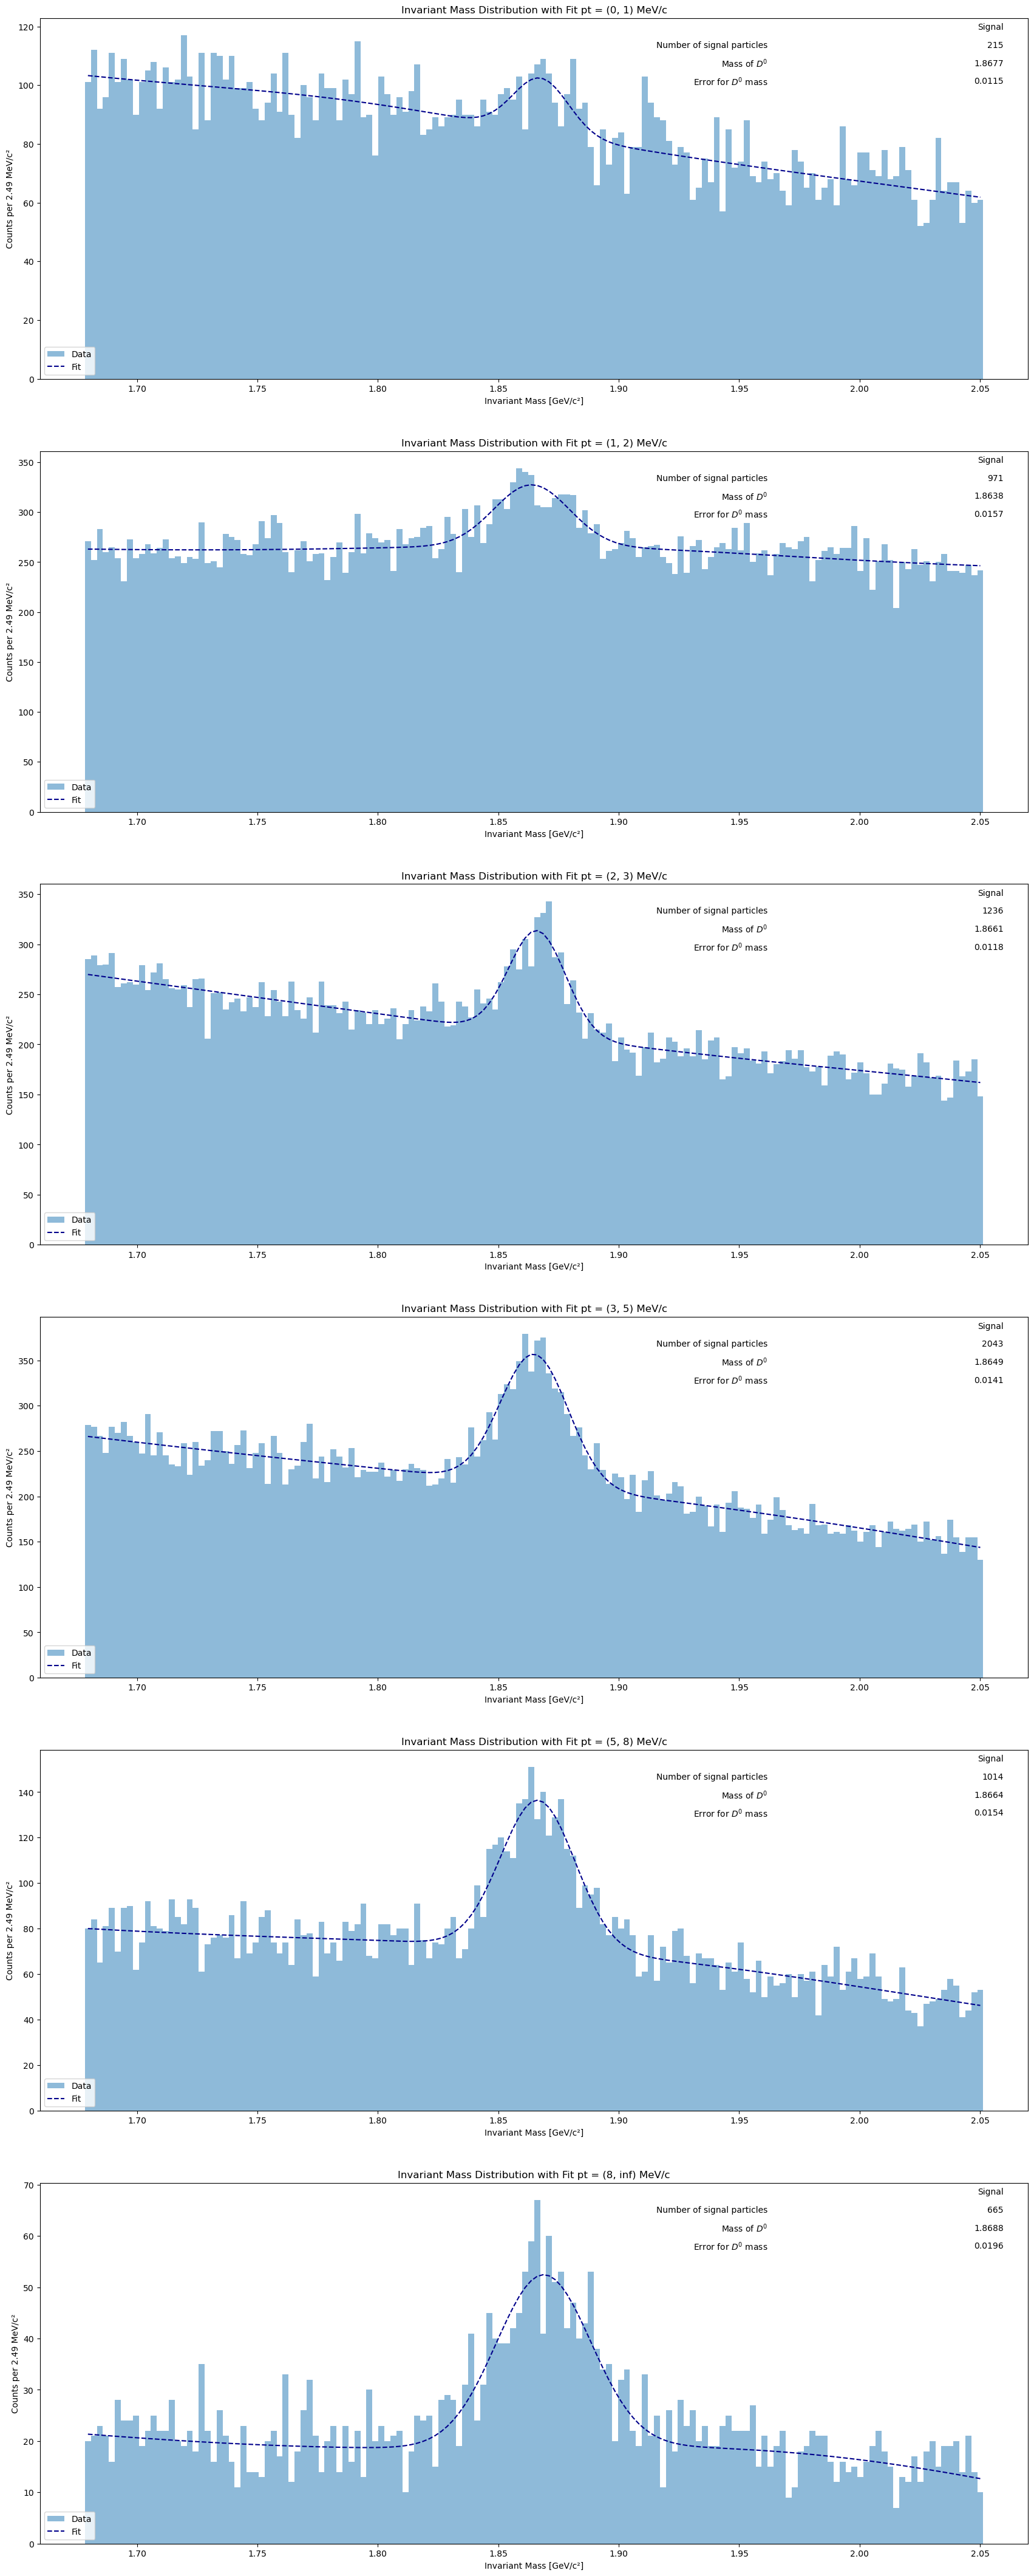

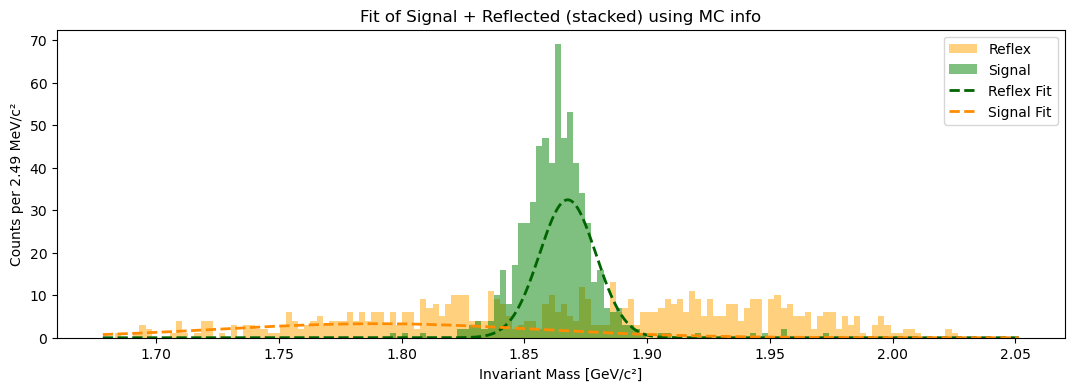

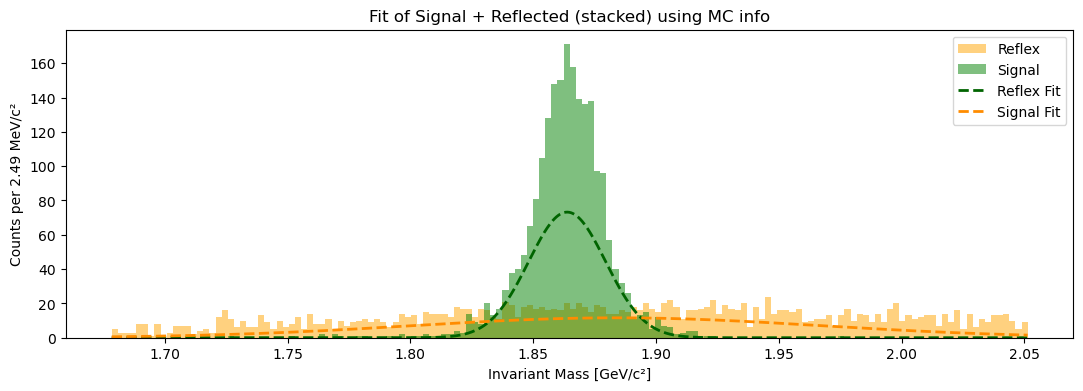

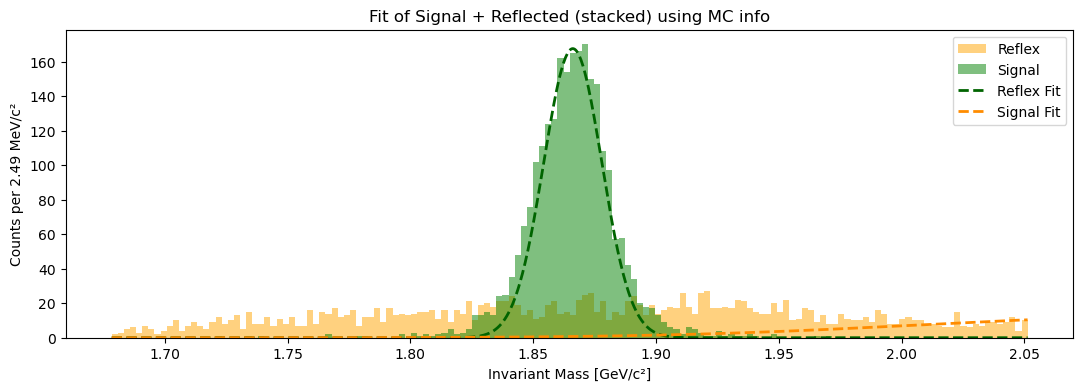

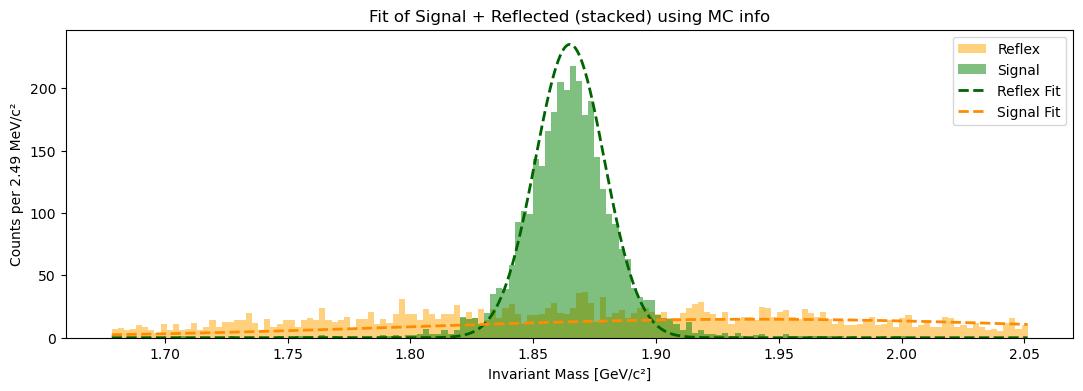

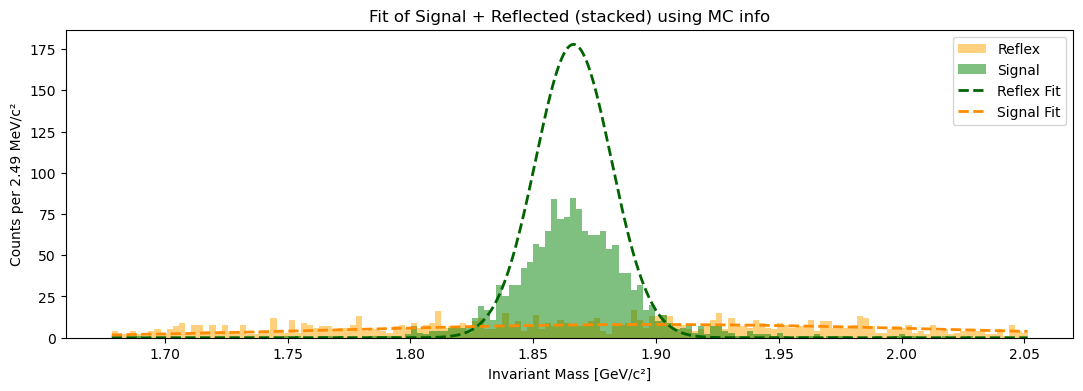

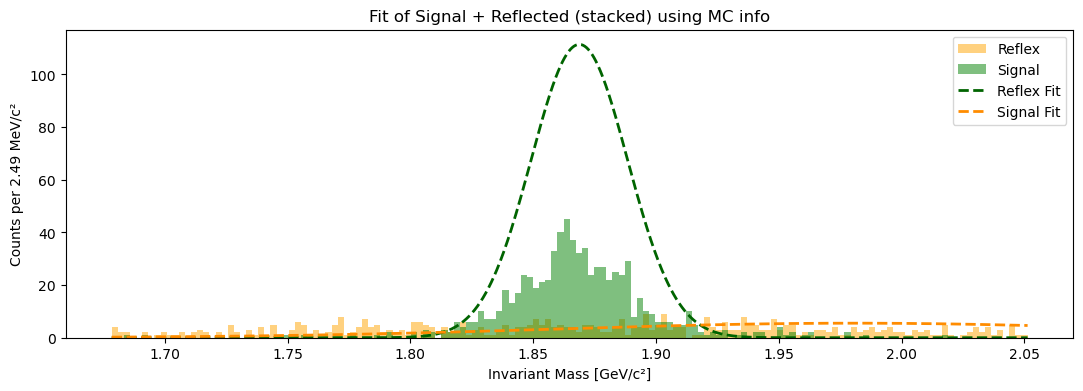

,Pt_interval,D0_counts,D0_mass,k,m1,s1,m2,s2,a,b
0,"[0, 1]",215.002246,1.867660,0.706949,1.867660,0.011497,1.789863,0.064650,-109.057864,285.419332
1,"[1, 2]",971.425499,1.863820,2.635437,1.863820,0.015665,1.884053,0.083020,-47.890868,342.834439
2,"[2, 3]",1236.054328,1.866117,3.904890,1.866117,0.011813,2.107309,0.101370,-326.528977,818.245758
3,"[3, 5]",2042.903589,1.864925,6.489013,1.864925,0.014056,1.940239,0.136723,-359.105934,866.195342
4,"[5, 8]",1013.687410,1.866425,4.162073,1.866425,0.015416,1.898042,0.125341,-100.472267,245.880248
5,"[8, inf]",665.231057,1.868782,3.012158,1.868782,0.019641,1.980897,0.119441,-45.238199,96.909094


In [14]:
# --- perform the fit per pt interval to count the reconstructed 

# --- Fit function: double Gaussian + linear background ---
#ratio =  ratio_from_fit   # fixed ratio between Gaussians

def fit_function(x, k, mu1, sigma1, mu2, sigma2, a, b, ratio):
    return k * (ratio*norm.pdf(x, loc=mu1, scale=sigma1) + norm.pdf(x, loc=mu2, scale=sigma2)) + a*x + b

def make_fit_function_ratio(ratio):
    def fit_function_ratio(x, k, mu1, sigma1, mu2, sigma2, a, b):
        return fit_function(x, k, mu1, sigma1, mu2, sigma2, a, b, ratio)
    return fit_function_ratio

# list to store informations about results of the fit
mu_1 = []
sigma_1 = []
mu_2 = []
sigma_2 = []
noise_coeff = []
noise_offset = []
reco_D0 = []
D0_mass = []
k_coeff = []
pt_int = []

# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 150
binsize = (MAX_MASS - MIN_MASS)/N_BINS
# --- Initial parameter guesses ---
k_param = 100
signal_params = [m_d0, 0.02]
mirror_params = [m_d0, 0.1]
back_params   = [133, 1000]

# define pt intervals
pt_extremes = [[0, 1] , [1,2] , [2,3] , [3,5] , [5,8] , [8, np.inf]]
times = len(pt_extremes)

# define the figures
fig, axs = plt.subplots( nrows = times, ncols = 1, figsize = ( 21, 9 * times ) )

# perform the fit
for i in range( times ) :
    pt_lim = pt_extremes[ i ]
    ax = axs[ i ]

    fit_function_ratio = make_fit_function_ratio(k_ref_sig_pt[i])
    data_pt = data[data['pt'].between(pt_lim[0], pt_lim[1])]['mass']

    # HISTOGRAM:
    both_counts, both_edges, _ = ax.hist(data_pt, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Data')
    both_centers = (both_edges[:-1] + both_edges[1:]) / 2.0
    # --- Poisson errors ---
    sigma_hist = np.sqrt(both_counts)
    sigma_hist = np.clip(sigma_hist, 1, None)  # avoid zeros

    # FIT:
    both_fit_res = curve_fit( f = fit_function_ratio, xdata = both_centers, ydata = both_counts, sigma = sigma_hist,
                                p0 = [k_param, 
                                      signal_params[0], signal_params[1],
                                      mirror_params[0], mirror_params[1],
                                      back_params[0], back_params[1]
                                     ]
                            )
    both_params = both_fit_res[0]
    mu1, sigma1 = both_params[1], both_params[2]
    mu2, sigma2 = both_params[3], both_params[4]
    k_fit = both_params[0]

    # PLOT of fitted curve:
    ax.plot(
        both_centers,
        fit_function_ratio( both_centers, both_params[0], both_params[1], both_params[2],
            both_params[3], both_params[4], both_params[5], both_params[6]
        ),
        color='darkblue', linestyle='dashed', linewidth=1.5, label='Fit'
    )

    # COUNT of D0:
    mass_from_fit = both_params[1]
    sigma_from_fit = both_params[2]
    ratio = k_ref_sig_pt[i]
    counts_from_fit = both_params[0] * ratio * (norm.cdf(MAX_MASS, loc=mu1, scale=sigma1) - norm.cdf(MIN_MASS, loc=mu1, scale=sigma1)) /binsize

    # TABLE INSIDE PLOT:
    ax.table(
        cellText = [[f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"]],
        rowLabels = [r'Number of signal particles', r'Mass of $D^0$', r'Error for $D^0$ mass'],
        colLabels = ['Signal'],
        colLoc = "right",
        bbox = [0.75, 0.8, 0.25, 0.2],
        edges = 'open',
        rowLoc = 'right'
    )
    
    ax.set_xlabel("Invariant Mass [GeV/c²]")
    ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
    ax.set_title(f"Invariant Mass Distribution with Fit pt = {pt_lim[0], pt_lim[1]} MeV/c")
    ax.legend(loc='lower left') 

    #update the list to store the results
    pt_int.append(pt_lim)
    mu_1.append(mu1)
    sigma_1.append(sigma1)
    mu_2.append(mu2)
    sigma_2.append(sigma2)
    noise_coeff.append(both_params[5])
    noise_offset.append(both_params[6])
    reco_D0.append(counts_from_fit)
    D0_mass.append(mass_from_fit)
    k_coeff.append(k_fit)

    # new plot 
    # Histogram of signal and rflected part data only without cuts
    mask_pt_range = (final_results['pt'] >= pt_lim[0]) & (final_results['pt'] < pt_lim[1])

    # reflected part:
    data_inv_mass_true_ref   = final_results.loc[ mask_true_d0 & mask_pt_range, 'anti_mass'].values
    data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0 & mask_pt_range, 'inv_mass'].values
    reflex_data = np.concatenate( [ data_inv_mass_true_ref, data_anti_mass_true_ref] )
    # signal:
    data_inv_mass_true   = final_results.loc[ mask_true_d0 & mask_pt_range, 'inv_mass'].values
    data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & mask_pt_range, 'anti_mass'].values
    signal_data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )

    # Stacked histogram
    fig, ax_hist = plt.subplots(figsize=(13,4))
    
    # HISTOGRAM:
    # ------- reflex component:
    reflex_counts, reflex_edges, _ = ax_hist.hist(reflex_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Reflex', color='orange')
    reflex_centers = (reflex_edges[:-1] + reflex_edges[1:]) / 2.0
    # poisson errors:
    sigma_reflex_hist = np.sqrt(reflex_counts)
    sigma_reflex_hist = np.clip(sigma_reflex_hist, 1, None)  # avoid zeros
    # ------- signal:
    sign_counts, sign_edges, _ = ax_hist.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
    sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
    # poisson errors:
    sigma_sign_hist = np.sqrt(sign_counts)
    sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros

    #fino a qui ok----------------------------------------------------------------------------------------------------
    
    # PLOT of fitted curves:
    x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
    ax_hist.plot(x_fit, fit_gauss_mc(x_fit, k_fit/k_ref_sig_pt[i], mu1, sigma1), '--', color='darkgreen', linewidth=2, label='Reflex Fit')
    ax_hist.plot(x_fit, fit_gauss_mc(x_fit, k_fit*k_ref_sig_pt[i], mu2, sigma2), '--', color='darkorange', linewidth=2, label='Signal Fit')
    
    
    ax_hist.set_xlabel("Invariant Mass [GeV/c²]")
    ax_hist.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
    ax_hist.set_title("Fit of Signal + Reflected (stacked) using MC info")
    ax_hist.legend()


#--------------------------------------------------------------------


recap = pd.DataFrame({
    "Pt_interval": pt_int,
    "D0_counts": reco_D0,
    "D0_mass": D0_mass,
    "k": k_coeff,
    "m1": mu_1,
    "s1": sigma_1,
    "m2": mu_2,
    "s2": sigma_2,
    "a": noise_coeff,
    "b": noise_offset
})
plt.show()

recap





In [15]:
tot_reco_D0 = sum([ j for j in recap["D0_counts"] if j > 0 ])
tot_reco_D0

6144.304128432574

## Generated particles

In [16]:
# Count how many REAL D0 we have in the fitted dataset (real reconstructed D0)
generated_D0  = final_results[mask_true_d0]
generated_anti_D0 = final_results[mask_true_anti_d0]
print(f"In the dataset there are {len(generated_D0)} D0 generated by MC simulation")
print(f"In the dataset there are {len(generated_anti_D0)} D0 generated by MC simulation")

In the dataset there are 5230 D0 generated by MC simulation
In the dataset there are 5561 D0 generated by MC simulation


In [17]:
total_eff = tot_reco_D0/(len(generated_D0)+len(generated_anti_D0))
print("Raw efficiency: ", total_eff)

Raw efficiency:  0.5693915418805091


In [18]:
base_path = "/home/pira/Documenti/PoD/LCP/LCP_B/ALICE/Simulation"
which_chunk = ["001_010", "011_020", "021_030", "031_040", "041_050", "051_060", "061_070", "071_080", "081_090", "091_100" ]
which_file = "AO2Dtree.root"

acceptance = 0.8

gen_particles = []
gen_anti_particles = []
gen_D_0 = 0

# file by file...
for chunk in which_chunk:
    file = uproot.open(base_path + "/" + chunk + "/" + which_file)
    all_files = file.keys(filter_name = r"DF_*")
    file_ID = list(set([code.split("/")[0] for code in all_files]))
    # remove the directoryes code
    file_ID = [s for s in file_ID if not s.endswith(";1")]



    for directory in file_ID:
    
        # merge the genparticles an mccollision dataframes on fIndexMcCollisions
        generated_part = file[directory + "/O2genparticles"].arrays(library="pd")
        mc_collision_df = file[directory + "/O2mccollision"].arrays(library="pd")
        generated_part = pd.merge(left=generated_part, right=mc_collision_df, how='inner', left_on='fIndexMcCollisions', right_index=True)
        
    
        # DEFINING MASKS to decrease the number of columns by summarizing them:
        mask_true_d0 = (
            (generated_part["fPosZ"].abs() < 10) &
            (generated_part["fMainMotherY"].abs() < acceptance) &
            (generated_part["fPdgCode"] == 421) &
            (generated_part["fMainBeautyAncestorPdgCode"] == 0) 
            #(generated_part["fMainMotherNfinalStateDaught"] == 2) 
        )
        mask_true_anti_d0 = (
            (generated_part["fPosZ"].abs() < 10) &
            (generated_part["fMainMotherY"].abs() < acceptance) &
            (generated_part["fPdgCode"] == -421) &
            (generated_part["fMainBeautyAncestorPdgCode"] == 0) 
            #(generated_part["fMainMotherNfinalStateDaught"] == 2) 
        )
    
        # apply the mask
        generated_part_true_d0 = generated_part[mask_true_d0]
        generated_part_true_anti_d0 = generated_part[mask_true_anti_d0]
        
        # count the generated particles selected after the cuts file by file
        n_gen_D_0 = len(generated_part_true_d0)+len(generated_part_true_anti_d0)
        #print("In this file there are", len(generated_part_true_d0), "D_0", len(generated_part_true_anti_d0), "anti-D0")
    
        # Update the total number of generated particles
        gen_D_0 += n_gen_D_0 
    
        gen_particles.append(generated_part_true_d0)
        gen_anti_particles.append(generated_part_true_anti_d0)

In [19]:
gen_D_0

329686

In [20]:
total_eff = tot_reco_D0/gen_D_0
print("Raw efficiency: ", total_eff)


Raw efficiency:  0.018636836651943284


In [21]:
# Pt intervals and labels
Pt_intervals = [0, 1, 2, 3, 5, 8, 41]
Pt_labels = ["0-1", "1-2", "2-3", "3-5", "5-8", "8-41"]

gen_D0_Pt = []
gen_anti_D0_Pt = []

# particles
for data_frame in gen_particles:
    data_frame = data_frame.copy()
    data_frame.loc[:,"interval"] = pd.cut(data_frame['fMainMotherPt'], bins=Pt_intervals, labels=Pt_labels, right=True, include_lowest=True)
    r = data_frame.groupby("interval", observed=True).size()
    gen_D0_Pt.append(r)

tot_D0_Pt = reduce(lambda x, y: x.add(y, fill_value=0), gen_D0_Pt)
tot_D0_Pt_df = tot_D0_Pt.reset_index()
tot_D0_Pt_df.columns = ['Pt_Interval', 'Count_D0']

#anti particles
for data_frame in gen_anti_particles:
    data_frame = data_frame.copy()
    data_frame.loc[:,"interval"] = pd.cut(data_frame['fMainMotherPt'], bins=Pt_intervals, labels=Pt_labels, right=True, include_lowest=True)
    r = data_frame.groupby("interval", observed=True).size()
    gen_anti_D0_Pt.append(r)

tot_anti_D0_Pt = reduce(lambda x, y: x.add(y, fill_value=0), gen_anti_D0_Pt)
tot_anti_D0_Pt_df = tot_anti_D0_Pt.reset_index()
tot_anti_D0_Pt_df.columns = ['Pt_Interval', 'Count_anti_D0']


In [22]:
tot_part = pd.merge(tot_D0_Pt_df, tot_anti_D0_Pt_df, on='Pt_Interval', how='inner')
tot_part["tot"] = tot_part["Count_D0"]+tot_part["Count_anti_D0"]
tot_part 

,Pt_Interval,Count_D0,Count_anti_D0,tot
0,0-1,35107.0,34617.0,69724.0
1,1-2,49299.0,49259.0,98558.0
2,2-3,33972.0,34166.0,68138.0
3,3-5,30615.0,30883.0,61498.0
4,5-8,11700.0,11631.0,23331.0
5,8-41,4272.0,4139.0,8411.0


In [23]:
eff_num = np.array(recap["D0_counts"]) 
eff_den = np.array(tot_part["tot"])
eff = eff_num/eff_den
eff

array([0.00308362, 0.00985638, 0.01814046, 0.03321902, 0.04344809,
       0.0790906 ])

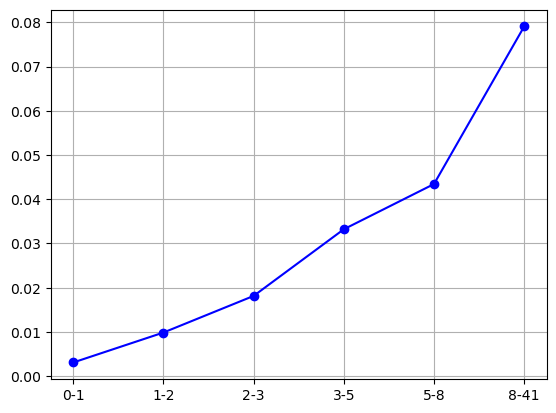

In [24]:
plt.plot(Pt_labels, eff, marker='o', linestyle='-', color='blue')
plt.grid()

In [ ]:
# errore propagazine binomiale